Name: Juan Diego Amaya Cueva


In [1]:
import site
site.main()
import viz
from functools import partial

import time

import matplotlib.pyplot as plt
import numpy as np
import pinocchio as pin
import trimesh
from robot_descriptions.loaders.pinocchio import load_robot_description

from viz import PinNotebookViz, add_mesh_handle, create_server, update_object_pose

server, share_url = create_server()
notebook_viz = PinNotebookViz(server)
add_mesh_handle = partial(add_mesh_handle, server)

print(f"Open the visualizer here: {share_url}")

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://marquee-offline.share.viser.studio

Open the visualizer here: https://marquee-offline.share.viser.studio


In [13]:
go2 = load_robot_description ("go2_description")
model = go2.model
data = model.createData()
q_neutral = pin.neutral (model)
base = model.getFrameId("base")

In [14]:
notebook_viz.attach_robot(go2, root_name="Quadruped")
notebook_viz.display(pin.neutral(model))
notebook_viz.show_frame("world", pin.SE3.Identity(), axes_length=0.20)

FrameHandle(show_axes=True, axes_length=0.2, axes_radius=0.008, origin_radius=0.016, origin_color=(236, 236, 0), scale=1.0)

In [4]:
q0 = np.zeros(model.nq)
v0 = np.zeros(model.nv)
notebook_viz.display(q0)
print (f"nq: {model.nq}, nv: {model.nv}")

nq: 12, nv: 12


In [5]:
M = pin.crba(model, data, q0)
h = pin.nle(model, data, q0, v0)

print (f"Shape of M: {M.shape}\nShape of h: {h.shape}")

Shape of M: (12, 12)
Shape of h: (12,)


In [6]:
def simulate_with_aba(acceleration_function, steps=1000, dt=0.01):
    q = q0.copy()
    v = v0.copy()
    trajectory = []
    for k in range(steps):
        tau = np.zeros(model.nv)
        a = acceleration_function(q, v, tau)
        q = pin.integrate(model, q, v * dt)  # use old v first
        v = v + a * dt                        # then update v
        trajectory.append(q.copy())
    return trajectory

def simulate_with_rbe (model, data, steps = 1000, dt= 0.01):
    "M(q) · a = τ − h(q, v), tau = 0"
    q = q0.copy()
    v = v0.copy()
    trajectory = []
    for k in range (steps):
        M = pin.crba(model, data, q)
        h = pin.nle(model, data, q, v)
        a = np.linalg.solve(M, -h)
        q_next = q + v * dt
        v_next = v + a * dt
        q = q_next
        v = v_next
        trajectory.append(q.copy())
    return trajectory

acceleration_function_aba = lambda q, v, tau: pin.aba(model, data, q, v, tau)


    

In [7]:
# Simulate with aba
trajectory_aba = simulate_with_aba (acceleration_function_aba)

for q_k in trajectory_aba [:]:
    notebook_viz.display(q_k)
    time.sleep(0.01)


In [8]:
# Simulate with own algebraic solution
trajectory_rbe = simulate_with_rbe (model, data)

for q_k in trajectory_rbe [:]:
    notebook_viz.display(q_k)
    time.sleep(0.01)


(viser) Connection opened (0, 1 total), 428 persistent messages

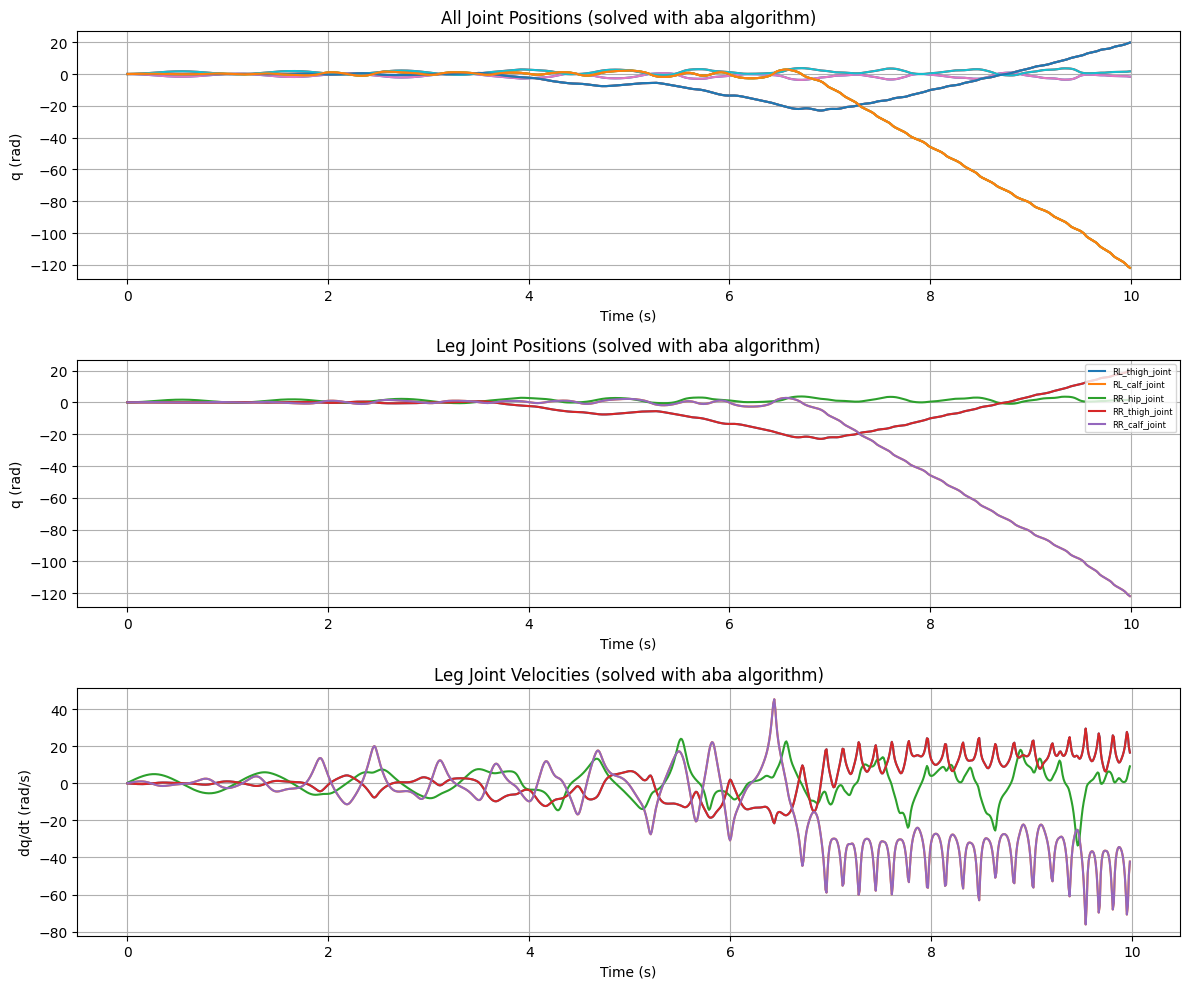

In [9]:
import matplotlib.pyplot as plt


traj_array = np.array(trajectory_aba)
steps = len(trajectory_aba)
dt = 0.01
time_vec = np.arange(steps) * dt
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# --- All joints overview ---
axes[0].plot(time_vec, traj_array)
axes[0].set_title("All Joint Positions (solved with aba algorithm)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("q (rad)")
axes[0].grid(True)

leg_indices = list(range(7, model.nq))   # adjust if fixed base (start from 0)
axes[1].plot(time_vec, traj_array[:, leg_indices])
axes[1].set_title("Leg Joint Positions (solved with aba algorithm)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("q (rad)")
axes[1].legend([model.names[i+1] for i in leg_indices], fontsize=6, loc="upper right")
axes[1].grid(True)

velocities = np.diff(traj_array, axis=0) / dt
axes[2].plot(time_vec[:-1], velocities[:, leg_indices])
axes[2].set_title("Leg Joint Velocities (solved with aba algorithm)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("dq/dt (rad/s)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

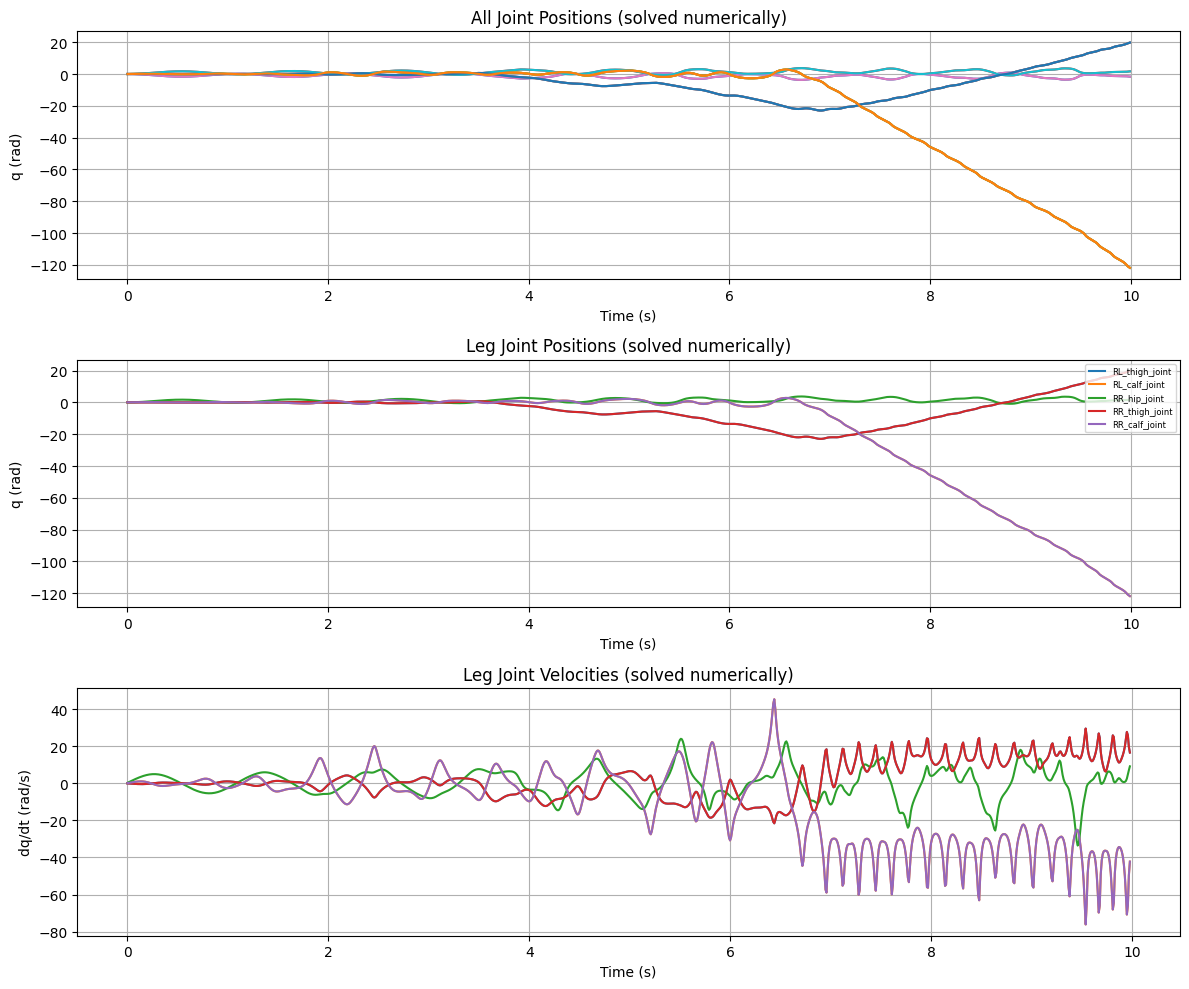

In [10]:

traj_array = np.array(trajectory_rbe)
steps = len(trajectory_aba)
dt = 0.01
time_vec = np.arange(steps) * dt
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# --- All joints overview ---
axes[0].plot(time_vec, traj_array)
axes[0].set_title("All Joint Positions (solved numerically)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("q (rad)")
axes[0].grid(True)

leg_indices = list(range(7, model.nq))   # adjust if fixed base (start from 0)
axes[1].plot(time_vec, traj_array[:, leg_indices])
axes[1].set_title("Leg Joint Positions (solved numerically)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("q (rad)")
axes[1].legend([model.names[i+1] for i in leg_indices], fontsize=6, loc="upper right")
axes[1].grid(True)

velocities = np.diff(traj_array, axis=0) / dt
axes[2].plot(time_vec[:-1], velocities[:, leg_indices])
axes[2].set_title("Leg Joint Velocities (solved numerically)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("dq/dt (rad/s)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [23]:
floating_robot = load_robot_description (
    "go2_description",
    root_joint=pin.JointModelFreeFlyer()
)
print(f"floating-base nq = {floating_robot.model.nq}, nv = {floating_robot.model.nv}")
notebook_viz.attach_robot(floating_robot, root_name="flotating_go2")
q_floating = pin.neutral(floating_robot.model)
q_floating[:3] = np.array([0.0, 0.0, 0.8])
notebook_viz.display(q_floating)
q_floating[:10]
data_floating = floating_robot.model.createData()

floating-base nq = 19, nv = 18


In [24]:
def simulate_floating_base(model, data, steps=1000, dt=0.01):
    q = pin.neutral(model)  # correct initial config (quaternion = [0,0,0,1])
    v = np.zeros(model.nv)
    trajectory = []

    for k in range(steps):
        tau = np.zeros(model.nv)
        
        # 1. ABA solves M*a = tau - h, same equation as before
        a = pin.aba(model, data, q, v, tau)
        
        # 2. Euler integration on flat velocity space
        v_next = v + a * dt
        
        # 3. Euler integration on configuration manifold (handles quaternion)
        q_next = pin.integrate(model, q, v * dt)  # use OLD v
        
        q = q_next
        v = v_next
        trajectory.append(q.copy())

    return trajectory

In [25]:
trajectory_floating = simulate_floating_base (floating_robot.model, data_floating)

for q_k in trajectory_floating [:]:
    notebook_viz.display(q_k)
    time.sleep(0.01)

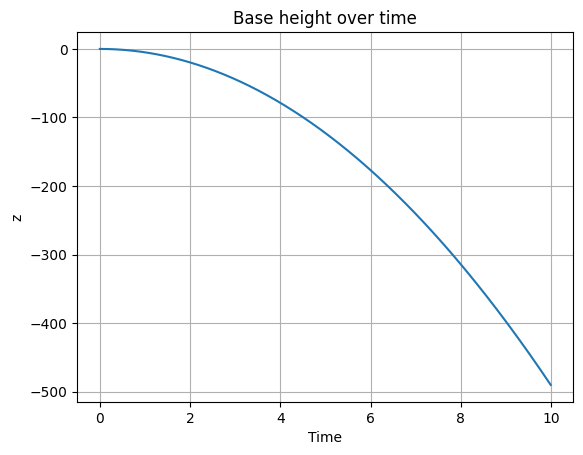

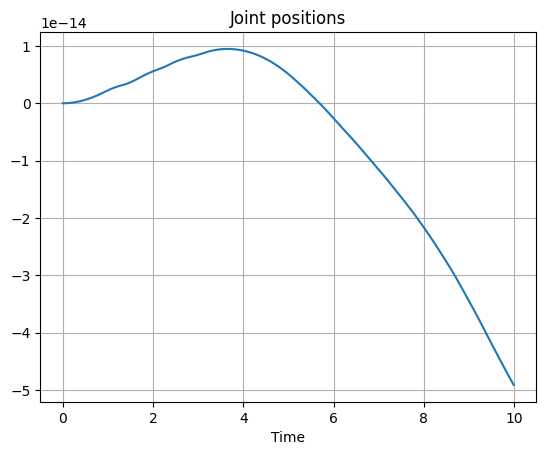

In [30]:
traj_array = np.array(trajectory_floating)

plt.Figure()
plt.plot(time_vec, traj_array[:, 2], label="base z")
plt.title("Base height over time")
plt.xlabel("Time")
plt.ylabel("z")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time_vec, traj_array[:,7])
plt.title("Joint positions")
plt.xlabel("Time")
plt.grid(True)
plt.show()